# Impressions exploration

This workbook helps you inspect a raw impressions dataset at the event level.

It follows a two-step flow:
1. Apply baseline cleaning aligned with the main pipeline:
   - remove duplicate impressions,
   - keep homepage rows,
   - remove sessions with more than 50 article impressions.
2. Perform exploratory user outlier trimming (top-N or impression cap) to inspect how many extreme users remain.

This way, the baseline population matches pipeline logic as closely as possible, while still allowing custom outlier what-if analysis in the notebook.

Note: the CSV files currently in this folder are already aggregated by category, so they are not suitable for session-level or user-level impression analysis. Point this notebook to a raw impressions export or use the S3 path in the config cell below.


In [1]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    import awswrangler as wr
    import boto3
except ImportError:
    wr = None
    boto3 = None

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", message=".*tight_layout.*")

In [4]:
# Set DATA_SOURCE to "s3" or "csv" depending on where your raw event-level impressions live.
DATA_SOURCE = "s3"

# If you want to load a local raw export instead, update this path and set DATA_SOURCE = "csv".
LOCAL_DATA_PATH = "path/to/raw_impressions.csv"

# Default S3 location based on the existing scripts in this workspace.
S3_PATH = "s3://recosearch-nps-bucket-shared-with-smit/vk/impressions/"

# Column names used for the filtering and aggregation steps.
USER_COL = "MAPPED_USER_IDENTIFIER"
SESSION_COL = "SESSION_ID"
ARTICLE_COL = "ARTICLE_IDENTIFIER"

# Filtering controls.
SESSION_ARTICLE_LIMIT = 50  # Remove sessions with more than this many distinct articles read

# Optional columns for outlier overview (use None if not present in data).
TIME_ON_PAGE_COL = "TIME_ON_PAGE"
START_TIME_COL = "START_TIME"
EVENT_TYPE_COL = "event_type"  # From S3 path partition; may not exist

# Env var fallbacks used by the existing scripts in this folder.
AWS_ACCESS_KEY_ID_ENV = "DPG_ACCESS_KEY_ID"
AWS_SECRET_ACCESS_KEY_ENV = "DPG_SECRET_ACCESS_KEY"

In [6]:
def _resolve_env(primary_name: str, fallback_name: str) -> str | None:
    value = os.getenv(primary_name)
    if value:
        return value
    return os.getenv(fallback_name)


def load_impressions_df() -> pd.DataFrame:
    if load_dotenv is not None:
        load_dotenv()

    if DATA_SOURCE == "csv":
        path = Path(LOCAL_DATA_PATH).expanduser()
        if not path.exists():
            raise FileNotFoundError(f"Local CSV not found: {path}")
        return pd.read_csv(path)

    if DATA_SOURCE == "s3":
        if wr is None or boto3 is None:
            raise ImportError("awswrangler and boto3 are required to read from S3.")

        access_key = _resolve_env(AWS_ACCESS_KEY_ID_ENV, "")
        secret_key = _resolve_env(AWS_SECRET_ACCESS_KEY_ENV, "")

        session_kwargs = {}
        if access_key and secret_key:
            session_kwargs = {
                "aws_access_key_id": access_key,
                "aws_secret_access_key": secret_key,
            }

        boto3_session = boto3.session.Session(**session_kwargs)
        return wr.s3.read_csv(path=S3_PATH, boto3_session=boto3_session)

    raise ValueError(f"Unsupported DATA_SOURCE: {DATA_SOURCE}")


df_raw = load_impressions_df()
df_raw.columns = [str(col).strip() for col in df_raw.columns]

print(f"Loaded {len(df_raw):,} rows and {len(df_raw.columns):,} columns")
display(df_raw.head())
display(pd.DataFrame({"column": df_raw.columns}))

Loaded 4,969,473 rows and 58 columns


,"{""added"":[]","removed:[""_SUCCESS""]}","{""added"":[""part-00000-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-644-1.c000.csv""",part-00001-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-645-1.c000.csv,part-00002-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-646-1.c000.csv,part-00003-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-647-1.c000.csv,part-00004-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-648-1.c000.csv,part-00005-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-649-1.c000.csv,part-00006-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-650-1.c000.csv,part-00007-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-651-1.c000.csv],"removed:[""_SUCCESS""",part-00000-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-3-1.c000.csv,part-00001-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-4-1.c000.csv,part-00002-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-5-1.c000.csv,part-00003-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-6-1.c000.csv,part-00004-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-7-1.c000.csv,part-00005-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-8-1.c000.csv,part-00006-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-9-1.c000.csv,part-00007-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-10-1.c000.csv,part-00008-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-11-1.c000.csv,part-00009-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-12-1.c000.csv,part-00010-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-13-1.c000.csv,part-00011-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-14-1.c000.csv]},"{""added"":[""part-00000-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-3-1.c000.csv""",part-00011-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-14-1.c000.csv],removed:[]},NUMBER_ITEMS_IMPRESSED,TIME_ON_PAGE,MAX_SCROLL_DEPTH,ARTICLE_TEXT_LENGTH,ARTICLE_IDENTIFIER,IMPRESSION_ID,START_TIME,SESSION_ID,IS_LOGGED_IN,MAPPED_USER_IDENTIFIER,"{""added"":[""part-00000-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-644-2.c000.csv""",part-00001-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-645-2.c000.csv,part-00002-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-646-2.c000.csv,part-00003-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-647-2.c000.csv,part-00004-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-648-2.c000.csv,part-00005-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-649-2.c000.csv,part-00006-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-650-2.c000.csv,part-00007-tid-1214957551897766303-9bff6305-ace6-480b-9fd7-d4c3d572544e-651-2.c000.csv],part-00000-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-3-2.c000.csv,part-00001-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-4-2.c000.csv,part-00002-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-5-2.c000.csv,part-00003-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-6-2.c000.csv,part-00004-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-7-2.c000.csv,part-00005-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-8-2.c000.csv,part-00006-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-9-2.c000.csv,part-00007-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-10-2.c000.csv,part-00008-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-11-2.c000.csv,part-00009-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-12-2.c000.csv,part-00010-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-13-2.c000.csv,part-00011-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d256-14-2.c000.csv]},"{""added"":[""part-00000-tid-1759972473398524279-5cc18a9d-0966-4bcd-b441-11a2eae1d

,column
0,"{""added"":[]"
1,"removed:[""_SUCCESS""]}"
2,"{""added"":[""part-00000-tid-1214957551897766303-..."
3,part-00001-tid-1214957551897766303-9bff6305-ac...
4,part-00002-tid-1214957551897766303-9bff6305-ac...
5,part-00003-tid-1214957551897766303-9bff6305-ac...
6,part-00004-tid-1214957551897766303-9bff6305-ac...
7,part-00005-tid-1214957551897766303-9bff6305-ac...
8,part-00006-tid-1214957551897766303-9bff6305-ac...
9,part-00007-tid-1214957551897766303-9bff6305-ac...


In [7]:
required_cols = [USER_COL, SESSION_COL, ARTICLE_COL]
missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df = df_raw.copy()
for col in [USER_COL, SESSION_COL, ARTICLE_COL]:
    df[col] = df[col].astype("string").str.strip()

rows_before = len(df)

# Keep homepage rows for baseline cleaning: only require user/session IDs.
df = df[df[USER_COL].notna() & df[SESSION_COL].notna()].copy()
df = df[(df[USER_COL] != "") & (df[SESSION_COL] != "")].copy()
rows_after_user_session_filter = len(df)

# Align with pipeline duplicate removal as closely as possible.
dedupe_subset = [USER_COL, ARTICLE_COL]
if START_TIME_COL and START_TIME_COL in df.columns:
    dedupe_subset.append(START_TIME_COL)

dedupe_subset = [c for c in dedupe_subset if c in df.columns]
rows_before_dedupe = len(df)
if dedupe_subset:
    df = df.drop_duplicates(subset=dedupe_subset, keep="first").copy()
rows_after_dedupe = len(df)

# Pipeline-aligned session filter:
# remove sessions with > 50 ARTICLE IMPRESSIONS (not distinct articles),
# while keeping homepage rows in the retained sessions.
article_values = df[ARTICLE_COL].astype("string").str.strip()
is_article_impression = (
    article_values.notna()
    & (article_values != "")
    & (article_values != "nan")
    & (article_values != "<NA>")
)

session_article_impressions = (
    df.loc[is_article_impression]
    .groupby(SESSION_COL)
    .size()
    .rename("session_article_impressions")
)

all_session_ids = df[SESSION_COL].dropna().astype("string")
session_article_impressions = session_article_impressions.reindex(all_session_ids.unique(), fill_value=0)

sessions_to_remove = session_article_impressions[
    session_article_impressions > SESSION_ARTICLE_LIMIT
].index

df_standard_filtered = df[~df[SESSION_COL].isin(sessions_to_remove)].copy()

session_filter_summary = pd.DataFrame(
    {
        "metric": [
            "raw rows",
            "rows after dropping blank user/session ids",
            "rows removed as duplicates",
            "rows after dedupe",
            "distinct sessions before filter",
            "sessions removed (>50 article impressions)",
            "rows after baseline filtering",
        ],
        "value": [
            rows_before,
            rows_after_user_session_filter,
            rows_before_dedupe - rows_after_dedupe,
            rows_after_dedupe,
            all_session_ids.nunique(),
            len(sessions_to_remove),
            len(df_standard_filtered),
        ],
    }
)

display(session_filter_summary)

display(session_article_impressions.describe().to_frame(name="value").T)

,metric,value
0,raw rows,4969473
1,rows after dropping blank user/session ids,4969473
2,rows removed as duplicates,2313
3,rows after dedupe,4967160
4,distinct sessions before filter,1274591
5,sessions removed (>50 article impressions),272
6,rows after baseline filtering,4915073


,count,mean,std,min,25%,50%,75%,max
value,1274591.0,1.836239,4.273766,0.0,0.0,1.0,2.0,504.0


In [20]:
# Exploratory user outlier removal (intentional notebook-only step):
# use ONE of the two (whichever is specified takes precedence).
# - IMPRESSION_LIMIT_TO_INCLUDE: remove all users with total impressions above this threshold
# - TOP_N_USER_OUTLIERS_TO_REMOVE: remove the top N users by impression count
IMPRESSION_LIMIT_TO_INCLUDE = None  # e.g. 1000 to exclude users with >1000 impressions
TOP_N_USER_OUTLIERS_TO_REMOVE = 5   # e.g. 5000 to remove top 5000 users with the most impressions

user_impressions = (
    df_standard_filtered.groupby(USER_COL)
    .size()
    .rename("total_impressions")
    .sort_values(ascending=False)
    .reset_index()
)

# Apply removal strategy: IMPRESSION_LIMIT takes precedence if set
if IMPRESSION_LIMIT_TO_INCLUDE is not None:
    removed_outlier_users = user_impressions[
        user_impressions["total_impressions"] > IMPRESSION_LIMIT_TO_INCLUDE
    ][USER_COL].tolist()
    user_impressions_trimmed = user_impressions[
        user_impressions["total_impressions"] <= IMPRESSION_LIMIT_TO_INCLUDE
    ].reset_index(drop=True)
    removal_method = f"impression_limit<={IMPRESSION_LIMIT_TO_INCLUDE}"
elif TOP_N_USER_OUTLIERS_TO_REMOVE and TOP_N_USER_OUTLIERS_TO_REMOVE > 0:
    removed_outlier_users = user_impressions.head(TOP_N_USER_OUTLIERS_TO_REMOVE)[USER_COL].tolist()
    user_impressions_trimmed = user_impressions.iloc[TOP_N_USER_OUTLIERS_TO_REMOVE:].reset_index(drop=True)
    removal_method = f"top_n={TOP_N_USER_OUTLIERS_TO_REMOVE}"
else:
    removed_outlier_users = []
    user_impressions_trimmed = user_impressions.copy()
    removal_method = "none"

df_exploration_filtered = df_standard_filtered[
    ~df_standard_filtered[USER_COL].isin(removed_outlier_users)
].copy()

user_summary = pd.DataFrame(
    {
        "metric": [
            "distinct users before exploratory removal",
            "users removed",
            "distinct users after exploratory removal",
            "rows after exploratory removal",
        ],
        "value": [
            user_impressions.shape[0],
            len(removed_outlier_users),
            user_impressions_trimmed.shape[0],
            len(df_exploration_filtered),
        ],
    }
)

display(user_summary)
display(user_impressions_trimmed.head(10))

if removed_outlier_users:
    print(f"Removal method: {removal_method}")
    print(f"Removed {len(removed_outlier_users)} users")

,metric,value
0,distinct users before exploratory removal,200358
1,users removed,5
2,distinct users after exploratory removal,200353
3,rows after exploratory removal,4817219


,MAPPED_USER_IDENTIFIER,total_impressions
0,73773.0,1541
1,132238.0,1336
2,76003.0,1310
3,159387.0,1154
4,61379.0,1080
5,190849.0,981
6,58373.0,861
7,143559.0,817
8,36773.0,816
9,64358.0,805


Removal method: top_n=5
Removed 5 users


In [18]:
# Top 10 most extreme remaining outliers (after exploratory user removal)
TOP_N_OUTLIERS_OVERVIEW = 10
top_10_user_ids = user_impressions_trimmed.head(TOP_N_OUTLIERS_OVERVIEW)[USER_COL].tolist()
top_10_user_ids = [str(uid).strip() for uid in top_10_user_ids]
sessions_ok = set(df_standard_filtered[SESSION_COL].astype(str))

# Use raw data for full event coverage (homepage + article)
df_clean = df_raw.copy()
df_clean.columns = [str(c).strip() for c in df_clean.columns]
for col in [USER_COL, SESSION_COL]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("string").str.strip().replace("nan", "")

df_outliers = df_clean[
    df_clean[USER_COL].isin(top_10_user_ids)
    & df_clean[SESSION_COL].isin(sessions_ok)
    & (df_clean[USER_COL] != "") & (df_clean[SESSION_COL] != "")
].copy()

# Infer homepage vs article: event_type if present, else ARTICLE_IDENTIFIER
if EVENT_TYPE_COL and EVENT_TYPE_COL in df_outliers.columns:
    is_homepage = df_outliers[EVENT_TYPE_COL].astype(str).str.lower() == "home_page_view"
    is_article = df_outliers[EVENT_TYPE_COL].astype(str).str.lower() == "article_page_view"
else:
    art = df_outliers.get(ARTICLE_COL)
    has_article = art.notna() & (art.astype(str).str.strip() != "") & (art.astype(str) != "nan")
    is_homepage = ~has_article
    is_article = has_article

# Build per-user overview
rows = []
for uid in top_10_user_ids:
    mask = df_outliers[USER_COL] == uid
    user_df = df_outliers[mask]
    user_home = user_df[is_homepage[mask]]
    user_art = user_df[is_article[mask]]

    n_sessions = user_df[SESSION_COL].nunique()
    homepage_impressions = len(user_home)
    total_article_impressions = len(user_art)
    # Count distinct articles read per session, based on ARTICLE_IDENTIFIER (not impression count)
    total_unique_articles = user_art[ARTICLE_COL].nunique() if len(user_art) > 0 else 0

    if TIME_ON_PAGE_COL and TIME_ON_PAGE_COL in df_outliers.columns:
        art_times = pd.to_numeric(user_art[TIME_ON_PAGE_COL], errors="coerce").dropna()
        avg_reading_time = art_times.mean() if len(art_times) > 0 else None
    else:
        avg_reading_time = None

    if START_TIME_COL and START_TIME_COL in df_outliers.columns:
        user_df = user_df.copy()
        user_df["_start"] = pd.to_datetime(user_df[START_TIME_COL], errors="coerce")
        session_durations = user_df.groupby(SESSION_COL)["_start"].agg(lambda x: x.max() - x.min())
        session_durations = session_durations.dropna()
        session_durations = session_durations.dt.total_seconds()
        avg_session_duration = session_durations.mean() if len(session_durations) > 0 else None
    else:
        avg_session_duration = None

    rows.append({
        "user_id": uid,
        "n_sessions": n_sessions,
        "homepage_impressions": homepage_impressions,
        "total_article_impressions": total_article_impressions,
        "total_unique_articles": total_unique_articles,
        "avg_reading_time_sec": avg_reading_time,
        "avg_session_duration_sec": avg_session_duration,
    })

outlier_overview = pd.DataFrame(rows)
display(outlier_overview)

,user_id,n_sessions,homepage_impressions,total_article_impressions,total_unique_articles,avg_reading_time_sec,avg_session_duration_sec
0,151172.0,3,64684,0,0,NaN,175465.958667
1,93371.0,1,22978,0,0,NaN,574335.514000
2,155935.0,1,4032,0,0,NaN,604580.086000
3,87766.0,48,3348,81,46,66.419753,1321.446021
4,156080.0,40,2742,0,0,NaN,5529.656975
5,73773.0,461,433,1108,248,79.746835,681.035356
6,132238.0,238,632,704,106,46.392045,909.751899
7,76003.0,343,517,793,222,109.003783,476.722685
8,159387.0,267,504,650,163,96.215385,609.989371
9,61379.0,80,604,476,133,22.100840,1438.647962


,value
count,200353.000000
mean,24.043658
std,47.452346
min,1.000000
25%,2.000000
50%,7.000000
75%,23.000000
max,1541.000000


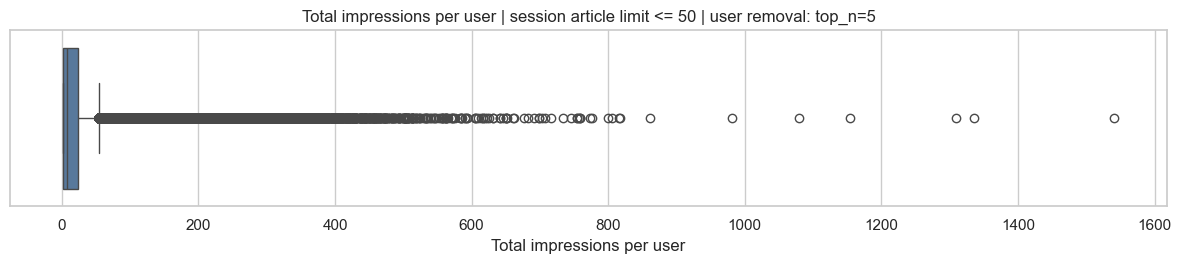

In [21]:
if user_impressions_trimmed.empty:
    raise ValueError("No users remain after filtering. Adjust IMPRESSION_LIMIT_TO_INCLUDE or TOP_N_USER_OUTLIERS_TO_REMOVE.")

distribution = user_impressions_trimmed["total_impressions"]
display(distribution.describe().to_frame(name="value"))

fig, ax = plt.subplots(figsize=(12, 2.8))
sns.boxplot(x=distribution, ax=ax, color="#4C78A8")
ax.set_title(
    "Total impressions per user"
    f" | session article limit <= {SESSION_ARTICLE_LIMIT}"
    f" | user removal: {removal_method}"
)
ax.set_xlabel("Total impressions per user")
plt.tight_layout()
plt.show()